# **City Landscape in Sight: A Crowdsourced Framework for Unlocking Urban-Scale Window View Perceptions from Real Estate Imagery**

**Authors:** [Chucai Peng](https://ual.sg/author/chucai-peng/)†, [Sijie Yang](https://sijie-yang.com)†, Ang Liu, Yang Xiang, Zhixiang Zhou, [Filip Biljecki](https://filipbiljecki.com)* 

by [Urban Analytics Lab](https://ual.sg), [Department of Architecture](https://cde.nus.edu.sg/arch/), [College of Design and Engineering](https://cde.nus.edu.sg), [National University of Singapore](https://www.nus.edu.sg)


---

(† co-first authors, * corresponding authors)

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).

# Code_3_Perception Model Train & Predict

This notebook trains and applies the *Window View Perception* regression model that maps a window-view image (plus tabular visual features) to a continuous TrueSkill score for each of six perception dimensions: **Prefer, Monotonous, Quiet, Extensive, Vivid, Oppressive**.

Prerequisites: **Code 1** (TrueSkill labels + `TrainingFeatures_*.csv`), **Code 2** (pre-processed images in `data/training_images/WVI_Processed/` and visual features in `Features.csv`).

Pipeline:
1. **Training tables** — load `data/training_features/TrainingFeatures_{dim}.csv` (re-run Code 1 §2.1 if labels change).
2. **Model** — ImageNet **ResNet‑50** (full fine-tuning) + concatenated tabular features → single regression output (MSE loss).
3. **Benchmark & inference** — K-fold multi-model comparison, checkpoints, and city-scale scoring.

Data sources used in this notebook:
- `data/training_features/TrainingFeatures_{dimension}.csv` (perception score + per-image features)
- `data/training_images/WVI_Processed/` (masked, cropped 256 px images from Code 2)
- `model_outputs/` (checkpoints, best-epoch metrics, per-epoch `training_history_*.csv`, written by this notebook)


## 0. Plotting Configuration

Run plotting configuration first — set up the overall style of figures.

In [1]:
import matplotlib as mpl
import seaborn as sns

sns.set_theme(context="paper", style="white", font_scale=0.9)

mpl.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "figure.autolayout": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "axes.linewidth": 0.6,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "legend.fontsize": 7,
    "legend.frameon": False,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

OKABE_ITO = [
    "#E69F00",
    "#56B4E9",
    "#009E73",
    "#F0E442",
    "#0072B2",
    "#D55E00",
    "#CC79A7",
    "#000000",
]
sns.set_palette(OKABE_ITO)

PERCEPTION_DIMS = ["prefer", "monotonous", "quiet", "extensive", "vivid", "oppressive"]
PERCEPTION_DIMS_TITLE = [d.capitalize() for d in PERCEPTION_DIMS]
perception_colors = {d: OKABE_ITO[i % len(OKABE_ITO)] for i, d in enumerate(PERCEPTION_DIMS)}
TRAINING_META_COLS = frozenset({"ID", "SampleWeight"})  # from Code 1; not model inputs


def training_aux_feature_columns(columns, dim: str) -> list[str]:
    return [c for c in columns if c not in TRAINING_META_COLS and c != dim]

INCH_PER_MM = 1.0 / 25.4
COL_WIDTH = 89 * INCH_PER_MM
DOUBLE_COL_WIDTH = 183 * INCH_PER_MM
FIG_HEIGHT_SMALL = 2.2
FIG_HEIGHT_MEDIUM = 2.8
FIG_HEIGHT_TALL = 3.4

def savefig_all(fig, basename, png_dpi=300, tight=True):
    out_base = Path(basename)
    out_base.parent.mkdir(parents=True, exist_ok=True)
    kwargs = {"bbox_inches": "tight", "pad_inches": 0.01} if tight else {}
    fig.savefig(str(out_base.with_suffix(".png")), dpi=png_dpi, **kwargs)
    fig.savefig(str(out_base.with_suffix(".svg")), **kwargs)

TRAINING_IMAGES_DIR = Path("data/training_images")
TRAIN_ORIGINAL_DIR = TRAINING_IMAGES_DIR / "WVI_Original"
TRAIN_IMG_DIR = TRAINING_IMAGES_DIR / "WVI_Processed"
TRAIN_SEGMENTATION_DIR = TRAINING_IMAGES_DIR / "WVI_Segmentation"
FEATURES_DIR = Path("data/training_features")
KFOLD_SPLITS_DIR = FEATURES_DIR / "kfold_splits"
USE_FROZEN_KFOLD_SPLITS = True  # data/training_features/kfold_splits/ (scripts/export_kfold_splits.py)


## 1. Training Feature Tables

The per-dimension training tables produced in Code 1 contain `ID`, the TrueSkill `Score` for that dimension, eleven semantic-segmentation ratios (sky, building, tree, …), `Floor`, and twelve color/texture descriptors.  Below we summarise the regression target distribution and feature ranges used during training.

In [3]:
import pandas as pd

training_tables = {dim: pd.read_csv(FEATURES_DIR / f"TrainingFeatures_{dim}.csv") for dim in PERCEPTION_DIMS}
example = training_tables["oppressive"]
print(f"TrainingFeatures_oppressive.csv shape: {example.shape}")
print("Columns:")
print(list(example.columns))

score_summary = pd.concat({dim: t[dim].describe() for dim, t in training_tables.items()}, axis=1)
print("\nTrueSkill score summary across dimensions:")
print(score_summary.round(3).to_string())

TrainingFeatures_oppressive.csv shape: (499, 26)
Columns:
['ID', 'oppressive', 'Sky', 'High rise building', 'Low rise building', 'Grass', 'Hard ground', 'Tree', 'Water', 'Railing', 'Road', 'Barren land', 'Building interior', 'Floor', 'Hue_Mean', 'Hue_Std', 'Saturation_Mean', 'Saturation_Std', 'Brightness_Mean', 'Brightness_Std', 'EdgePixelRatio', 'Entropy', 'Colorfulness', 'Contrast', 'Sharpness', 'Image_Variance']

TrueSkill score summary across dimensions:
        prefer  monotonous    quiet  extensive    vivid  oppressive
count  499.000     499.000  499.000    499.000  499.000     499.000
mean     2.500       2.500    2.500      2.500    2.500       2.500
std      1.448       1.448    1.448      1.448    1.448       1.448
min      0.000       0.000    0.000      0.000    0.000       0.000
25%      1.250       1.250    1.250      1.250    1.250       1.250
50%      2.500       2.500    2.500      2.500    2.500       2.500
75%      3.750       3.750    3.750      3.750    3.750      

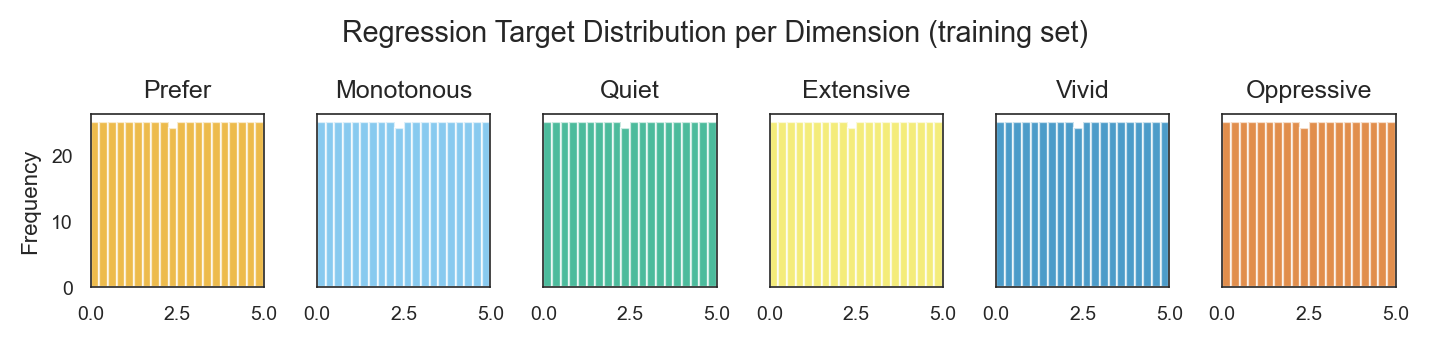

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_SMALL))
fig.suptitle("Regression Target Distribution per Dimension (training set)", y=0.85)
for ax, dim in zip(axes, PERCEPTION_DIMS):
    target = training_tables[dim][dim].dropna()
    ax.hist(target, bins=20, alpha=0.7, color=perception_colors[dim])
    ax.set_title(dim.capitalize())
    ax.set_xlim(0, 5)
    ax.set_box_aspect(1)
axes[0].set_ylabel("Frequency")
for ax in axes[1:]:
    ax.tick_params(axis="y", labelleft=False)
plt.tight_layout()
savefig_all(fig, "figures/code3_target_distribution")
plt.show()

## 2. Model Architecture

The regression model uses an ImageNet-pretrained **ResNet‑50** as the visual backbone, **end-to-end fine-tuned** (no frozen layers) together with the MLP head.  Tabular aux features are **standardised with `StandardScaler` fit on the train split** before concatenation.  The head uses dropout 0.5 and training minimises **MSE** loss.

$$
\hat{y} = \mathrm{MLP}\big(\mathrm{ResNet50}(x)\;\Vert\;\mathrm{scale}(f_\text{aux})\big),\quad
\mathrm{MLP}: 2048 + d_\text{aux} \to 512 \xrightarrow{\text{ReLU+Dropout(0.5)}} 1.
$$

In [5]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights


class WindowSceneRegressor(nn.Module):
    """ResNet-50 backbone (full fine-tune) + tabular features → single regression output."""

    def __init__(self, num_aux_features: int, dropout: float = 0.5):
        super().__init__()
        self.backbone = resnet50(weights=ResNet50_Weights.DEFAULT)
        cnn_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.head = nn.Sequential(
            nn.Linear(cnn_dim + num_aux_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 1),
        )

    def forward(self, image, aux):
        feats = self.backbone(image)
        return self.head(torch.cat((feats, aux), dim=1))


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def load_model(num_aux_features: int) -> WindowSceneRegressor:
    """CNN + aux features; all parameters trainable."""
    return WindowSceneRegressor(num_aux_features)


n_aux = len(training_aux_feature_columns(training_tables["oppressive"].columns, "oppressive"))
demo_model = load_model(n_aux)
print(f"Tabular features per image: {n_aux}")
print(f"Trainable params (ResNet-50 + head): {count_trainable_parameters(demo_model):,}")
print(demo_model.head)

Tabular features per image: 24
Trainable params (ResNet-50 + head): 24,569,921
Sequential(
  (0): Linear(in_features=2072, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=512, out_features=1, bias=True)
)


## 3. Dataset and Training Setup

Each `(image, aux_features) → score` example is wrapped in a torch `Dataset`.  Training images are augmented with random horizontal flips, small rotations and ColorJitter to mitigate the modest training-set size (~500 images per dimension).

K-fold CNN training below writes `model_outputs/kfold_cv_*.csv`. **Multi-model comparison** (tabular baselines vs Hybrid Neural Network) is in **§4** and can be run standalone without re-training.


In [6]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class WindowScenesDataset(Dataset):
    """Loads the masked + cropped 256 px image, its tabular features and the regression target."""

    def __init__(
        self,
        image_dir,
        score_csv,
        indices,
        labels,
        transform=None,
        aux_features: np.ndarray | None = None,
    ):
        self.image_dir = Path(image_dir)
        self.df = pd.read_csv(score_csv).iloc[indices].reset_index(drop=True)
        self.labels = list(labels)
        self.transform = transform
        self.aux_features = aux_features

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx, 0]
        path = self.image_dir / f"{img_id}.jpg"
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.aux_features is not None:
            aux = torch.tensor(self.aux_features[idx], dtype=torch.float32)
        else:
            aux = torch.tensor(self.df.iloc[idx, 2:].values.astype(np.float32))
        target = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, aux, target

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

#### training and evaluation helpers (regression + tolerance‑2 R² + binned metrics)

In [7]:
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score


def _mean_std(values) -> tuple[float, float]:
    """Sample mean and std (ddof=1) across K-fold test metrics."""
    s = pd.Series(values, dtype=float)
    return float(s.mean()), float(s.std(ddof=1))


def fmt_mean_std(mean: float, std: float, nd: int = 4) -> str:
    return f"{mean:.{nd}f}±{std:.{nd}f}"


def write_metrics_txt(
    path: Path,
    best_epoch: int,
    train_m: dict,
    val_m: dict,
    test_m: dict,
) -> None:
    """Write best-checkpoint metrics in the format used by §4 / Code 5."""
    lines = [
        f"Best Model Metrics (Epoch {best_epoch}; selected by validation R²):",
        (
            f"Train - Loss: {train_m['loss']:.4f}, R2: {train_m['r2']:.4f}, "
            f"MSE: {train_m['mse']:.4f}, MAE: {train_m['mae']:.4f}, RMSE: {train_m['rmse']:.4f}"
        ),
        f"Train - R2 Tolerance 2: {train_m['r2_tol2']:.4f}",
        (
            f"Validation - Loss: {val_m['loss']:.4f}, R2: {val_m['r2']:.4f}, "
            f"MSE: {val_m['mse']:.4f}, MAE: {val_m['mae']:.4f}, RMSE: {val_m['rmse']:.4f}"
        ),
        f"Validation - R2 Tolerance 2: {val_m['r2_tol2']:.4f}",
        (
            f"Test - Loss: {test_m['loss']:.4f}, R2: {test_m['r2']:.4f}, "
            f"MSE: {test_m['mse']:.4f}, MAE: {test_m['mae']:.4f}, RMSE: {test_m['rmse']:.4f}"
        ),
        f"Test - R2 Tolerance 2: {test_m['r2_tol2']:.4f}",
        "",
    ]
    path.write_text("\n".join(lines), encoding="utf-8")


def categorize(scores, n_bins):
    return pd.cut(scores, bins=n_bins, labels=False)

def classification_metrics(y_true, y_pred, n_bins):
    a = categorize(y_true, n_bins)
    b = categorize(y_pred, n_bins)
    return (
        accuracy_score(a, b),
        precision_score(a, b, average="weighted", zero_division=0),
        recall_score(a, b, average="weighted", zero_division=0),
        f1_score(a, b, average="weighted", zero_division=0),
    )

def tolerance_r2(y_true, y_pred, tol):
    adj = [p if abs(p - y) > tol else y for p, y in zip(y_pred, y_true)]
    return r2_score(y_true, adj)

def run_epoch(loader, model, criterion, optimizer, device, train: bool):
    model.train(train)
    losses, preds, labels = [], [], []
    for batch in loader:
        if batch is None:
            continue
        images, aux, target = (b.to(device) for b in batch)
        with torch.set_grad_enabled(train):
            out = model(images, aux).squeeze()
            loss = criterion(out, target.float())
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
        losses.append(loss.item())
        preds.extend(out.detach().cpu().numpy().ravel().tolist())
        labels.extend(target.detach().cpu().numpy().ravel().tolist())
    metrics = {
        "loss": float(np.mean(losses)),
        "r2": r2_score(labels, preds),
        "r2_tol2": tolerance_r2(labels, preds, 2),
        "mse": mean_squared_error(labels, preds),
        "mae": float(np.mean(np.abs(np.array(labels) - np.array(preds)))),
        "rmse": float(np.sqrt(mean_squared_error(labels, preds))),
    }
    for n_bins in (5, 3, 2):
        acc, prec, rec, f1 = classification_metrics(labels, preds, n_bins)
        metrics[f"acc_{n_bins}c"] = acc
        metrics[f"f1_{n_bins}c"] = f1
    return metrics

#### orchestrate training (all six dimensions)


**Frozen k-fold splits** (`USE_FROZEN_KFOLD_SPLITS = True`): loads `data/training_features/kfold_splits/kfold_split_{dim}.json` (image **ID** lists, stratification scores from Code 1).

**K-fold CV** (`RUN_KFOLD_CV = True`): each fold uses one stratified **test** fold (~20%); the remaining pool is split **train / val** (same 60:20 ratio as hold-out). Early stopping on **val**; metrics reported on fold **test**. Outputs **R² / MSE / RMSE mean±std** over folds → `kfold_cv_{dim}.csv`, `kfold_cv_summary.csv`. Checkpoint `best_model_{dim}.pth` = fold with highest fold test R².

Optional **single hold-out** (`RUN_TRAINING` / `TRAIN_ALL_DIMENSIONS`): stratified 60/20/20 (`SPLIT_SEED=42`).

Outputs under `MODEL_OUTPUT_DIR` (e.g. `model_outputs`).


In [8]:
import json
import time
import torch.optim as optim

MODEL_OUTPUT_DIR = Path("model_outputs")
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import joblib
from sklearn.preprocessing import StandardScaler

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.6, 0.2, 0.2
MAX_EPOCHS = 60
EARLY_STOPPING_PATIENCE = 10

from sklearn.model_selection import StratifiedKFold, train_test_split

SPLIT_SEED = 42
N_FOLDS = 5
SCORE_BIN_LABELS = ["[0,1)", "[1,2)", "[2,3)", "[3,4)", "[4,5]"]
VAL_FRAC_WITHIN_TRAIN_POOL = VAL_FRAC / (TRAIN_FRAC + VAL_FRAC)


def score_stratum(y: np.ndarray) -> np.ndarray:
    """Map 0–5 targets to strata 0–4 for [0,1) … [4,5] (5.0 → top bin)."""
    y = np.asarray(y, dtype=float)
    return np.clip(np.floor(y).astype(int), 0, len(SCORE_BIN_LABELS) - 1)


def stratified_train_val_test_indices(
    y: np.ndarray,
    train_frac: float = TRAIN_FRAC,
    val_frac: float = VAL_FRAC,
    test_frac: float = TEST_FRAC,
    seed: int = SPLIT_SEED,
) -> tuple[list[int], list[int], list[int]]:
    """Stratified 60/20/20 split on score bins; fixed seed for reproducibility."""
    if abs(train_frac + val_frac + test_frac - 1.0) > 1e-6:
        raise ValueError("train_frac + val_frac + test_frac must equal 1")
    y = np.asarray(y, dtype=float)
    strata = score_stratum(y)
    idx = np.arange(len(y))
    idx_trainval, idx_test = train_test_split(
        idx, test_size=test_frac, stratify=strata, random_state=seed
    )
    rel_val = val_frac / (train_frac + val_frac)
    strata_trainval = strata[idx_trainval]
    idx_train, idx_val = train_test_split(
        idx_trainval,
        test_size=rel_val,
        stratify=strata_trainval,
        random_state=seed,
    )
    return sorted(idx_train.tolist()), sorted(idx_val.tolist()), sorted(idx_test.tolist())


def stratified_kfold_train_val_test_splits(
    y: np.ndarray,
    n_folds: int = N_FOLDS,
    seed: int = SPLIT_SEED,
) -> list[tuple[list[int], list[int], list[int]]]:
    """Per fold: stratified test fold; train pool split into train+val (60/20-like ratio)."""
    y = np.asarray(y, dtype=float)
    strata = score_stratum(y)
    idx = np.arange(len(y))
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    folds = []
    for fold_i, (tr_rel, te_rel) in enumerate(skf.split(idx, strata), start=1):
        test_idx = idx[te_rel]
        trainval_idx = idx[tr_rel]
        tv_strata = strata[trainval_idx]
        rel = np.arange(len(trainval_idx))
        tr_rel_in, va_rel_in = train_test_split(
            rel,
            test_size=VAL_FRAC_WITHIN_TRAIN_POOL,
            stratify=tv_strata,
            random_state=seed + fold_i,
        )
        train_idx = trainval_idx[tr_rel_in]
        val_idx = trainval_idx[va_rel_in]
        folds.append(
            (
                sorted(train_idx.tolist()),
                sorted(val_idx.tolist()),
                sorted(test_idx.tolist()),
            )
        )
    return folds


def print_stratified_split_summary(dim: str, y: np.ndarray, train_idx, val_idx, test_idx) -> None:
    strata = score_stratum(y)
    splits = {"train": train_idx, "val": val_idx, "test": test_idx}
    print(
        f"[{dim}] stratified split (seed={SPLIT_SEED}, bins {SCORE_BIN_LABELS}): "
        f"train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}",
        flush=True,
    )
    for label, sid in splits.items():
        counts = pd.Series(strata[sid]).value_counts().sort_index()
        parts = [f"{SCORE_BIN_LABELS[i]}:{counts.get(i, 0)}" for i in range(len(SCORE_BIN_LABELS))]
        print(f"  {label:5s} " + ", ".join(parts), flush=True)




KFOLD_SPLITS_DIR = Path("data/training_features/kfold_splits")
USE_FROZEN_KFOLD_SPLITS = True


def _load_frozen_kfold_manifest(dim: str, splits_dir: Path = KFOLD_SPLITS_DIR) -> dict | None:
    path = splits_dir / f"kfold_split_{dim}.json"
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def frozen_stratify_y_from_manifest(manifest: dict, df: pd.DataFrame) -> np.ndarray:
    lut = {s["ID"]: float(s["score"]) for s in manifest["samples"]}
    return np.array([lut[str(i)] for i in df["ID"].astype(str)], dtype=float)


def align_frozen_kfold_folds(manifest: dict, df: pd.DataFrame) -> list[tuple[list[int], list[int], list[int]]]:
    lookup = {str(i): idx for idx, i in enumerate(df["ID"].astype(str))}
    frozen_ids = {s["ID"] for s in manifest["samples"]}
    if set(lookup) != frozen_ids:
        raise ValueError(
            f"[{manifest['dim']}] ID set mismatch vs frozen k-fold splits "
            f"(missing={len(frozen_ids - set(lookup))}, extra={len(set(lookup) - frozen_ids)})"
        )
    folds = []
    for fold in manifest["folds"]:
        tr = sorted(lookup[i] for i in fold["train_ids"])
        va = sorted(lookup[i] for i in fold["val_ids"])
        te = sorted(lookup[i] for i in fold["test_ids"])
        folds.append((tr, va, te))
    return folds



def collate_skipping_none(batch):
    """Drop None samples (e.g. missing images) before default_collate."""
    batch = [b for b in batch if b is not None]
    return torch.utils.data.dataloader.default_collate(batch) if batch else None


def _fit_train_eval_fold(
    dim: str,
    df: pd.DataFrame,
    y: np.ndarray,
    aux_cols: list[str],
    train_idx: list[int],
    val_idx: list[int],
    test_idx: list[int],
    fold_i: int,
    n_folds: int,
    device: torch.device,
    n_epochs: int,
    early_stopping_patience: int,
    batch_size: int,
    seed: int,
) -> tuple[dict, dict, dict, int, dict | None, StandardScaler]:
    """Train one fold; return train/val/test metrics, best_epoch, best_state, aux_scaler."""
    score_csv = FEATURES_DIR / f"TrainingFeatures_{dim}.csv"
    n_aux = len(aux_cols)
    aux_raw = df[aux_cols].values.astype(np.float64)
    aux_scaler = StandardScaler()
    aux_scaler.fit(aux_raw[train_idx])
    aux_scaled = aux_scaler.transform(aux_raw).astype(np.float32)

    train_loader = DataLoader(
        WindowScenesDataset(
            TRAIN_IMG_DIR, score_csv, train_idx, y[train_idx], train_transform, aux_scaled[train_idx]
        ),
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed + fold_i),
        collate_fn=collate_skipping_none,
    )
    val_loader = DataLoader(
        WindowScenesDataset(
            TRAIN_IMG_DIR, score_csv, val_idx, y[val_idx], eval_transform, aux_scaled[val_idx]
        ),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_skipping_none,
    )
    test_loader = DataLoader(
        WindowScenesDataset(
            TRAIN_IMG_DIR, score_csv, test_idx, y[test_idx], eval_transform, aux_scaled[test_idx]
        ),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_skipping_none,
    )

    model = load_model(n_aux).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    best_val_r2, best_epoch, best_state = -np.inf, 0, None
    epochs_no_improve = 0
    t_fold_start = time.time()

    for epoch in range(n_epochs):
        train_metrics = run_epoch(train_loader, model, criterion, optimizer, device, train=True)
        val_metrics = run_epoch(val_loader, model, criterion, optimizer, device, train=False)
        scheduler.step()
        if val_metrics["r2"] > best_val_r2:
            best_val_r2 = val_metrics["r2"]
            best_epoch = epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        elapsed = time.time() - t_fold_start
        mark = "★" if epochs_no_improve == 0 and val_metrics["r2"] == best_val_r2 else " "
        print(
            f"{mark}  [{dim}] f{fold_i}/{n_folds} ep {epoch + 1:02d}/{n_epochs} ({elapsed/60:.1f} min) | "
            f"train R²={train_metrics['r2']:+.3f} | val R²={val_metrics['r2']:+.3f} "
            f"(best val {best_val_r2:+.3f} @ ep {best_epoch}, "
            f"no-improve {epochs_no_improve}/{early_stopping_patience})",
            flush=True,
        )
        if early_stopping_patience > 0 and epochs_no_improve >= early_stopping_patience:
            print(f"  [{dim}] fold {fold_i} early stop @ ep {epoch + 1}", flush=True)
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    train_m = run_epoch(train_loader, model, criterion, optimizer, device, train=False)
    val_m = run_epoch(val_loader, model, criterion, optimizer, device, train=False)
    test_m = run_epoch(test_loader, model, criterion, optimizer, device, train=False)
    return train_m, val_m, test_m, best_epoch, best_state, aux_scaler


def train_dimension_kfold(
    dim: str,
    n_folds: int = N_FOLDS,
    n_epochs: int = MAX_EPOCHS,
    early_stopping_patience: int = EARLY_STOPPING_PATIENCE,
    batch_size: int = 8,
    seed: int = SPLIT_SEED,
) -> pd.DataFrame:
    """K-fold: each fold has train/val/test; report fold test R²/MSE/RMSE mean±std."""
    device = torch.device(
        "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    )
    score_csv = FEATURES_DIR / f"TrainingFeatures_{dim}.csv"
    df = pd.read_csv(score_csv)
    if "ID" not in df.columns:
        raise ValueError(f"TrainingFeatures_{dim}.csv must include ID column for frozen splits")
    df["ID"] = df["ID"].astype(str)
    y = df[dim].values.astype(float)
    aux_cols = training_aux_feature_columns(df.columns, dim)

    manifest = _load_frozen_kfold_manifest(dim) if USE_FROZEN_KFOLD_SPLITS else None
    if manifest is not None:
        if manifest.get("n_folds", N_FOLDS) != n_folds:
            raise ValueError(f"[{dim}] frozen splits n_folds={manifest.get('n_folds')} != {n_folds}")
        folds = align_frozen_kfold_folds(manifest, df)
        y_strat = frozen_stratify_y_from_manifest(manifest, df)
        split_note = manifest.get("stratify_source", str(KFOLD_SPLITS_DIR / f"kfold_split_{dim}.json"))
        split_mode = "frozen IDs"
    else:
        folds = stratified_kfold_train_val_test_splits(y, n_folds=n_folds, seed=seed)
        y_strat = y
        split_note = str(score_csv)
        split_mode = "live stratify"

    print(
        f"[{dim}] {n_folds}-fold CV ({split_mode}, seed={seed}) | n={len(y)} | "
        f"stratify scores: {split_note} | "
        f"per fold: train/val from non-test pool, test=held-out fold",
        flush=True,
    )

    fold_rows = []
    best_test_r2 = -np.inf
    best_artifacts: tuple[dict, dict, dict, dict, StandardScaler, int, int] | None = None
    t_dim_start = time.time()

    for fold_i, (train_idx, val_idx, test_idx) in enumerate(folds, start=1):
        print(
            f"  [{dim}] fold {fold_i}/{n_folds} | train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}",
            flush=True,
        )
        train_m, val_m, test_m, best_epoch, best_state, aux_scaler = _fit_train_eval_fold(
            dim,
            df,
            y,
            aux_cols,
            train_idx,
            val_idx,
            test_idx,
            fold_i,
            n_folds,
            device,
            n_epochs,
            early_stopping_patience,
            batch_size,
            seed,
        )
        fold_rows.append(
            {
                "dimension": dim,
                "fold": fold_i,
                "n_train": len(train_idx),
                "n_val": len(val_idx),
                "n_test": len(test_idx),
                "best_epoch": best_epoch,
                "val_r2": val_m["r2"],
                "test_r2": test_m["r2"],
                "test_mse": test_m["mse"],
                "test_rmse": test_m["rmse"],
            }
        )
        print(
            f"  [{dim}] fold {fold_i} test | R²={test_m['r2']:+.4f} MSE={test_m['mse']:.4f} RMSE={test_m['rmse']:.4f}",
            flush=True,
        )
        if test_m["r2"] > best_test_r2 and best_state is not None:
            best_test_r2 = test_m["r2"]
            best_artifacts = (best_state, train_m, val_m, test_m, aux_scaler, best_epoch, fold_i)

    fold_df = pd.DataFrame(fold_rows)
    for col in ("test_r2", "test_mse", "test_rmse"):
        m, s = _mean_std(fold_df[col])
        fold_df[f"{col}_mean"] = m
        fold_df[f"{col}_std"] = s

    elapsed = (time.time() - t_dim_start) / 60
    print(
        f"[{dim}] K-fold test summary ({elapsed:.1f} min): "
        f"R² {fmt_mean_std(fold_df['test_r2_mean'].iloc[0], fold_df['test_r2_std'].iloc[0])} | "
        f"MSE {fmt_mean_std(fold_df['test_mse_mean'].iloc[0], fold_df['test_mse_std'].iloc[0])} | "
        f"RMSE {fmt_mean_std(fold_df['test_rmse_mean'].iloc[0], fold_df['test_rmse_std'].iloc[0])}",
        flush=True,
    )

    out_path = MODEL_OUTPUT_DIR / f"kfold_cv_{dim}.csv"
    fold_df.to_csv(out_path, index=False)
    print(f"[{dim}] per-fold log → {out_path}", flush=True)

    if best_artifacts is not None:
        best_state, train_m, val_m, test_m, aux_scaler, best_epoch, best_fold = best_artifacts
        joblib.dump(aux_scaler, MODEL_OUTPUT_DIR / f"aux_scaler_{dim}.joblib")
        torch.save(best_state, MODEL_OUTPUT_DIR / f"best_model_{dim}.pth")
        write_metrics_txt(
            MODEL_OUTPUT_DIR / f"best_model_{dim}_metrics.txt",
            best_epoch,
            train_m,
            val_m,
            test_m,
        )
        with open(MODEL_OUTPUT_DIR / f"best_model_{dim}_metrics.txt", "a") as f:
            f.write(
                f"\n# K-fold CV ({n_folds} folds); checkpoint = fold {best_fold} (highest fold test R²).\n"
                f"# Fold-test R² mean±std: {fmt_mean_std(fold_df['test_r2_mean'].iloc[0], fold_df['test_r2_std'].iloc[0])}\n"
                f"# Fold-test MSE mean±std: {fmt_mean_std(fold_df['test_mse_mean'].iloc[0], fold_df['test_mse_std'].iloc[0])}\n"
                f"# Fold-test RMSE mean±std: {fmt_mean_std(fold_df['test_rmse_mean'].iloc[0], fold_df['test_rmse_std'].iloc[0])}\n"
            )

    return fold_df


def train_dimension(
    dim: str,
    n_epochs: int = MAX_EPOCHS,
    early_stopping_patience: int = EARLY_STOPPING_PATIENCE,
    batch_size: int = 8,
    train_frac: float = TRAIN_FRAC,
    val_frac: float = VAL_FRAC,
    test_frac: float = TEST_FRAC,
    seed: int = SPLIT_SEED,
):
    device = torch.device(
        "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    )
    score_csv = FEATURES_DIR / f"TrainingFeatures_{dim}.csv"
    df = pd.read_csv(score_csv)
    y = df[dim].values.astype(float)
    train_idx, val_idx, test_idx = stratified_train_val_test_indices(
        y, train_frac=train_frac, val_frac=val_frac, test_frac=test_frac, seed=seed
    )
    print_stratified_split_summary(dim, y, train_idx, val_idx, test_idx)
    aux_cols = training_aux_feature_columns(df.columns, dim)

    print(f"[{dim}] 拟合 aux StandardScaler、构建 DataLoader …", flush=True)
    train_m, val_m, test_m, best_epoch, best_state, aux_scaler = _fit_train_eval_fold(
        dim,
        df,
        y,
        aux_cols,
        train_idx,
        val_idx,
        test_idx,
        fold_i=0,
        n_folds=1,
        device=device,
        n_epochs=n_epochs,
        early_stopping_patience=early_stopping_patience,
        batch_size=batch_size,
        seed=seed,
    )
    joblib.dump(aux_scaler, MODEL_OUTPUT_DIR / f"aux_scaler_{dim}.joblib")
    if best_state is not None:
        torch.save(best_state, MODEL_OUTPUT_DIR / f"best_model_{dim}.pth")
    write_metrics_txt(
        MODEL_OUTPUT_DIR / f"best_model_{dim}_metrics.txt",
        best_epoch,
        train_m,
        val_m,
        test_m,
    )
    print(f"[{dim}] hold-out final @ epoch {best_epoch}:", flush=True)
    for split_name, m in ("train", train_m), ("val", val_m), ("test", test_m):
        print(
            f"  {split_name:5s} R²={m['r2']:+.3f} | MSE={m['mse']:.4f} | RMSE={m['rmse']:.4f}",
            flush=True,
        )
    return pd.DataFrame([{"dimension": dim, "best_epoch": best_epoch, "test_r2": test_m["r2"]}])


RUN_KFOLD_CV = True
KFOLD_ALL_DIMENSIONS = True
RUN_HOLDOUT_TRAINING = False

if RUN_KFOLD_CV:
    kfold_tables = []
    summary_rows = []
    dims_kfold = PERCEPTION_DIMS if KFOLD_ALL_DIMENSIONS else ["prefer"]
    for i, dim in enumerate(dims_kfold, start=1):
        print(f"\n=== K-fold CV {dim} ({i}/{len(dims_kfold)}) ===", flush=True)
        fold_df = train_dimension_kfold(dim)
        kfold_tables.append(fold_df)
        summary_rows.append(
            {
                "dimension": dim,
                "test_r2_mean": fold_df["test_r2_mean"].iloc[0],
                "test_r2_std": fold_df["test_r2_std"].iloc[0],
                "test_mse_mean": fold_df["test_mse_mean"].iloc[0],
                "test_mse_std": fold_df["test_mse_std"].iloc[0],
                "test_rmse_mean": fold_df["test_rmse_mean"].iloc[0],
                "test_rmse_std": fold_df["test_rmse_std"].iloc[0],
            }
        )
    kfold_summary = pd.DataFrame(summary_rows)
    summary_path = MODEL_OUTPUT_DIR / "kfold_cv_summary.csv"
    kfold_summary.to_csv(summary_path, index=False)
    print("\n=== K-fold CV summary (fold test metrics, mean±std) ===")
    for _, row in kfold_summary.iterrows():
        print(
            f"  {row['dimension']:12s} | R² {fmt_mean_std(row['test_r2_mean'], row['test_r2_std'])} | "
            f"MSE {fmt_mean_std(row['test_mse_mean'], row['test_mse_std'])} | "
            f"RMSE {fmt_mean_std(row['test_rmse_mean'], row['test_rmse_std'])}"
        )
    print(f"Saved → {summary_path}")

RUN_TRAINING = False
TRAIN_ALL_DIMENSIONS = False

if RUN_TRAINING:
    train_dimension("extensive")

if TRAIN_ALL_DIMENSIONS:
    for i, dim in enumerate(PERCEPTION_DIMS, start=1):
        print(f"\n=== Hold-out training {dim} ({i}/{len(PERCEPTION_DIMS)}) ===", flush=True)
        train_dimension(dim)


=== K-fold CV prefer (1/6) ===
[prefer] 5-fold CV (frozen IDs, seed=42) | n=499 | stratify scores: /Users/sijieyang/Documents/GitHub/City-Landscape-In-Sight/data/training_features/TrainingFeatures_prefer.csv | per fold: train/val from non-test pool, test=held-out fold
  [prefer] fold 1/5 | train=299 val=100 test=100
★  [prefer] f1/5 ep 01/60 (0.2 min) | train R²=-0.447 | val R²=+0.432 (best val +0.432 @ ep 1, no-improve 0/10)
★  [prefer] f1/5 ep 02/60 (0.3 min) | train R²=+0.594 | val R²=+0.572 (best val +0.572 @ ep 2, no-improve 0/10)
★  [prefer] f1/5 ep 03/60 (0.4 min) | train R²=+0.655 | val R²=+0.683 (best val +0.683 @ ep 3, no-improve 0/10)
★  [prefer] f1/5 ep 04/60 (0.5 min) | train R²=+0.667 | val R²=+0.711 (best val +0.711 @ ep 4, no-improve 0/10)
★  [prefer] f1/5 ep 05/60 (0.6 min) | train R²=+0.692 | val R²=+0.756 (best val +0.756 @ ep 5, no-improve 0/10)
   [prefer] f1/5 ep 06/60 (0.7 min) | train R²=+0.772 | val R²=+0.756 (best val +0.756 @ ep 5, no-improve 1/10)
   [prefe

## 4. Multi-model K-fold Benchmark (standalone)

**Run this section alone** after §3 CNN training has finished (or after copying `model_outputs/kfold_cv_*.csv` from a prior run). No GPU / ResNet training required here.

- **Hybrid Neural Network** row: read from `model_outputs/kfold_cv_{dim}.csv` or `model_outputs/kfold_cv_summary.csv` (written by §3).
- **Tabular models** (Ridge, Lasso, …): same frozen K-fold splits as §3 (`data/training_features/kfold_splits/kfold_split_{dim}.json`), evaluated on each fold's **test** set.
- Outputs: `model_outputs/model_comparison_kfold_*_mean.csv`, `*_std.csv`, and `figures/code3_model_comparison_kfold_r2_heatmap.*` / `..._rmse_heatmap.*` (one figure each).


In [14]:
# --- §4 bootstrap (no §0–§3 required) ---
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from tqdm.auto import tqdm

try:
    import xgboost as xgb

    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed — XGBoost row will be omitted.")

# Paths (edit MODEL_OUTPUT_DIR if your §3 checkpoints live elsewhere)
FEATURES_DIR = Path("data/training_features")
KFOLD_SPLITS_DIR = FEATURES_DIR / "kfold_splits"
MODEL_OUTPUT_DIR = Path("model_outputs")
USE_FROZEN_KFOLD_SPLITS = True
N_FOLDS = 5
SPLIT_SEED = 42

PERCEPTION_DIMS = ["prefer", "monotonous", "quiet", "extensive", "vivid", "oppressive"]
PERCEPTION_DIMS_TITLE = [d.capitalize() for d in PERCEPTION_DIMS]
TRAINING_META_COLS = frozenset({"ID", "SampleWeight"})

INCH_PER_MM = 1.0 / 25.4
DOUBLE_COL_WIDTH = 183 * INCH_PER_MM
FIG_HEIGHT_MEDIUM = 2.8


def training_aux_feature_columns(columns, dim: str) -> list[str]:
    return [c for c in columns if c not in TRAINING_META_COLS and c != dim]


def savefig_all(fig, basename, png_dpi=300, tight=True):
    out_base = Path(basename)
    out_base.parent.mkdir(parents=True, exist_ok=True)
    kwargs = {"bbox_inches": "tight", "pad_inches": 0.01} if tight else {}
    fig.savefig(str(out_base.with_suffix(".png")), dpi=png_dpi, **kwargs)
    fig.savefig(str(out_base.with_suffix(".svg")), **kwargs)


def _mean_std(values) -> tuple[float, float]:
    s = pd.Series(values, dtype=float)
    return float(s.mean()), float(s.std(ddof=1))


def fmt_mean_std(mean: float, std: float, nd: int = 4) -> str:
    return f"{mean:.{nd}f}±{std:.{nd}f}"


def heatmap_mean_std_annot(mean_df: pd.DataFrame, std_df: pd.DataFrame, nd: int = 2) -> pd.DataFrame:
    """Shorter mean±std labels for heatmap cells (default 2 decimals)."""
    out = mean_df.astype(object).copy()
    for r in out.index:
        for c in out.columns:
            m, s = mean_df.loc[r, c], std_df.loc[r, c]
            if pd.notna(m):
                out.loc[r, c] = fmt_mean_std(m, s, nd=nd)
    return out


def kfold_heatmap_figsize(n_rows: int, n_cols: int) -> tuple[float, float]:
    """Scale figure size with matrix shape so cells stay readable."""
    width = max(DOUBLE_COL_WIDTH, 0.55 * n_cols + 2.0)
    height = max(3.2, 0.42 * n_rows + 1.8)
    return (width, height)


def _load_frozen_kfold_manifest(dim: str, splits_dir: Path = KFOLD_SPLITS_DIR) -> dict | None:
    path = splits_dir / f"kfold_split_{dim}.json"
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def align_frozen_kfold_folds(manifest: dict, df: pd.DataFrame) -> list[tuple[list[int], list[int], list[int]]]:
    lookup = {str(i): idx for idx, i in enumerate(df["ID"].astype(str))}
    frozen_ids = {s["ID"] for s in manifest["samples"]}
    if set(lookup) != frozen_ids:
        raise ValueError(
            f"[{manifest['dim']}] ID set mismatch vs frozen k-fold splits "
            f"(missing={len(frozen_ids - set(lookup))}, extra={len(set(lookup) - frozen_ids)})"
        )
    folds = []
    for fold in manifest["folds"]:
        tr = sorted(lookup[i] for i in fold["train_ids"])
        va = sorted(lookup[i] for i in fold["val_ids"])
        te = sorted(lookup[i] for i in fold["test_ids"])
        folds.append((tr, va, te))
    return folds


def load_training_table(dim: str) -> pd.DataFrame:
    df = pd.read_csv(FEATURES_DIR / f"TrainingFeatures_{dim}.csv")
    if "ID" not in df.columns:
        raise ValueError(f"TrainingFeatures_{dim}.csv must include an ID column")
    df["ID"] = df["ID"].astype(str)
    return df


def _parse_hybrid_kfold_summary(dim: str) -> dict[str, float] | None:
    """Read §3 CNN K-fold test metrics (mean±std) from disk."""
    per_dim = MODEL_OUTPUT_DIR / f"kfold_cv_{dim}.csv"
    if per_dim.exists():
        kdf = pd.read_csv(per_dim)
        if not kdf.empty and "test_r2_mean" in kdf.columns:
            return {
                "r2_mean": float(kdf["test_r2_mean"].iloc[0]),
                "r2_std": float(kdf["test_r2_std"].iloc[0]),
                "mse_mean": float(kdf["test_mse_mean"].iloc[0]),
                "mse_std": float(kdf["test_mse_std"].iloc[0]),
                "rmse_mean": float(kdf["test_rmse_mean"].iloc[0]),
                "rmse_std": float(kdf["test_rmse_std"].iloc[0]),
            }
        if not kdf.empty and "test_r2" in kdf.columns:
            r2_m, r2_s = _mean_std(kdf["test_r2"])
            mse_m, mse_s = _mean_std(kdf["test_mse"])
            rmse_m, rmse_s = _mean_std(kdf["test_rmse"])
            return {
                "r2_mean": r2_m,
                "r2_std": r2_s,
                "mse_mean": mse_m,
                "mse_std": mse_s,
                "rmse_mean": rmse_m,
                "rmse_std": rmse_s,
            }
    summary_path = MODEL_OUTPUT_DIR / "kfold_cv_summary.csv"
    if summary_path.exists():
        sdf = pd.read_csv(summary_path)
        row = sdf.loc[sdf["dimension"] == dim]
        if not row.empty:
            r = row.iloc[0]
            return {
                "r2_mean": float(r["test_r2_mean"]),
                "r2_std": float(r["test_r2_std"]),
                "mse_mean": float(r["test_mse_mean"]),
                "mse_std": float(r["test_mse_std"]),
                "rmse_mean": float(r["test_rmse_mean"]),
                "rmse_std": float(r["test_rmse_std"]),
            }
    return None


def _build_tabular_model(name: str, n_pls: int):
    if name == "Ridge":
        return Ridge(alpha=1.0)
    if name == "Lasso":
        return Lasso(alpha=0.1)
    if name == "ElasticNet":
        return ElasticNet(alpha=0.1, l1_ratio=0.5)
    if name == "PLS":
        return PLSRegression(n_components=n_pls)
    if name == "RandomForest":
        return RandomForestRegressor(n_estimators=100, random_state=SPLIT_SEED)
    if name == "SVR":
        return SVR(kernel="rbf")
    if name == "XGBoost":
        return xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=SPLIT_SEED)
    raise ValueError(name)


TABULAR_MODEL_NAMES = [
    "Ridge",
    "Lasso",
    "ElasticNet",
    "PLS",
    "RandomForest",
    "SVR",
    "XGBoost",
]

HYBRID_MODEL_NAME = "Hybrid Neural Network"
COMPARISON_MODEL_ORDER = TABULAR_MODEL_NAMES + [HYBRID_MODEL_NAME]


def benchmark_tabular_models_kfold_for_dim(dim: str) -> dict[str, dict[str, float]]:
    """Same K-fold train/val/test splits as §3 CNN; return test metric mean±std per model."""
    df = load_training_table(dim)
    y = df[dim].values.astype(np.float64)
    feat_cols = training_aux_feature_columns(df.columns, dim)
    X = df[feat_cols].values.astype(np.float64)

    manifest = _load_frozen_kfold_manifest(dim) if USE_FROZEN_KFOLD_SPLITS else None
    if manifest is None:
        raise FileNotFoundError(
            f"Frozen splits not found: {KFOLD_SPLITS_DIR / f'kfold_split_{dim}.json'}. "
            "Set USE_FROZEN_KFOLD_SPLITS=False only if you intend to re-split live."
        )
    folds = align_frozen_kfold_folds(manifest, df)

    n_pls = min(10, X.shape[1], max(1, len(folds[0][0]) - 1))
    results: dict[str, dict[str, float]] = {}

    for name in TABULAR_MODEL_NAMES:
        if name == "XGBoost" and not HAS_XGB:
            continue
        fold_r2, fold_mse, fold_rmse = [], [], []
        for train_idx, val_idx, test_idx in folds:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X[train_idx])
            X_test = scaler.transform(X[test_idx])
            model = _build_tabular_model(name, n_pls)
            model.fit(X_train, y[train_idx])
            pred = np.asarray(model.predict(X_test), dtype=float).ravel()
            fold_r2.append(float(r2_score(y[test_idx], pred)))
            fold_mse.append(float(mean_squared_error(y[test_idx], pred)))
            fold_rmse.append(float(np.sqrt(fold_mse[-1])))
        r2_m, r2_s = _mean_std(fold_r2)
        mse_m, mse_s = _mean_std(fold_mse)
        rmse_m, rmse_s = _mean_std(fold_rmse)
        results[name] = {
            "r2_mean": r2_m,
            "r2_std": r2_s,
            "mse_mean": mse_m,
            "mse_std": mse_s,
            "rmse_mean": rmse_m,
            "rmse_std": rmse_s,
        }

    hybrid_m = _parse_hybrid_kfold_summary(dim)
    if hybrid_m is not None:
        results[HYBRID_MODEL_NAME] = hybrid_m
    else:
        print(f"[{dim}] warning: no CNN k-fold results under {MODEL_OUTPUT_DIR} — Hybrid row omitted")
    return results


# --- load §3 CNN summary once (for console) ---
_summary_p = MODEL_OUTPUT_DIR / "kfold_cv_summary.csv"
if _summary_p.exists():
    print(f"Loaded K-fold summary: {_summary_p}")
else:
    print(f"No {_summary_p.name}; will try per-dimension kfold_cv_{{dim}}.csv")

r2_mean_df = pd.DataFrame(index=COMPARISON_MODEL_ORDER, columns=PERCEPTION_DIMS_TITLE, dtype=float)
r2_std_df = r2_mean_df.copy()
mse_mean_df = r2_mean_df.copy()
mse_std_df = r2_mean_df.copy()
rmse_mean_df = r2_mean_df.copy()
rmse_std_df = r2_mean_df.copy()
r2_annot_df = pd.DataFrame(index=COMPARISON_MODEL_ORDER, columns=PERCEPTION_DIMS_TITLE, dtype=object)

for dim, col_title in tqdm(
    list(zip(PERCEPTION_DIMS, PERCEPTION_DIMS_TITLE)),
    desc=f"K-fold benchmark ({N_FOLDS}-fold test mean±std)",
):
    per_model = benchmark_tabular_models_kfold_for_dim(dim)
    for model_name, metrics in per_model.items():
        if model_name not in r2_mean_df.index:
            for d in (r2_mean_df, r2_std_df, mse_mean_df, mse_std_df, rmse_mean_df, rmse_std_df, r2_annot_df):
                d.loc[model_name] = np.nan
        r2_mean_df.loc[model_name, col_title] = metrics["r2_mean"]
        r2_std_df.loc[model_name, col_title] = metrics["r2_std"]
        mse_mean_df.loc[model_name, col_title] = metrics["mse_mean"]
        mse_std_df.loc[model_name, col_title] = metrics["mse_std"]
        rmse_mean_df.loc[model_name, col_title] = metrics["rmse_mean"]
        rmse_std_df.loc[model_name, col_title] = metrics["rmse_std"]
        r2_annot_df.loc[model_name, col_title] = fmt_mean_std(metrics["r2_mean"], metrics["r2_std"], nd=3)

filled = r2_mean_df.notna().any(axis=1)
r2_mean_df = r2_mean_df.loc[filled]
r2_std_df = r2_std_df.loc[filled]
mse_mean_df = mse_mean_df.loc[filled]
mse_std_df = mse_std_df.loc[filled]
rmse_mean_df = rmse_mean_df.loc[filled]
rmse_std_df = rmse_std_df.loc[filled]
r2_annot_df = r2_annot_df.loc[filled]

prefix = MODEL_OUTPUT_DIR / "model_comparison_kfold"
r2_mean_df.to_csv(f"{prefix}_r2_mean.csv")
r2_std_df.to_csv(f"{prefix}_r2_std.csv")
mse_mean_df.to_csv(f"{prefix}_mse_mean.csv")
mse_std_df.to_csv(f"{prefix}_mse_std.csv")
rmse_mean_df.to_csv(f"{prefix}_rmse_mean.csv")
rmse_std_df.to_csv(f"{prefix}_rmse_std.csv")

print(f"\nK-fold test R² (mean±std, {N_FOLDS} folds):")
print(r2_annot_df.to_string())
print("\nRMSE mean:")
print(rmse_mean_df.round(4).to_string())
print("\nRMSE std:")
print(rmse_std_df.round(4).to_string())
print(f"\nSaved → {prefix}_*_mean.csv / *_std.csv")


Loaded K-fold summary: model_outputs/kfold_cv_summary.csv


K-fold benchmark (5-fold test mean±std):   0%|          | 0/6 [00:00<?, ?it/s]


K-fold test R² (mean±std, 5 folds):
                            Prefer   Monotonous        Quiet    Extensive        Vivid   Oppressive
Ridge                  0.670±0.066  0.288±0.039  0.375±0.057  0.655±0.037  0.376±0.045  0.573±0.079
Lasso                  0.663±0.030  0.276±0.050  0.395±0.056  0.643±0.029  0.370±0.034  0.576±0.067
ElasticNet             0.681±0.043  0.291±0.037  0.412±0.060  0.652±0.034  0.393±0.028  0.582±0.072
PLS                    0.671±0.066  0.279±0.044  0.372±0.056  0.655±0.037  0.378±0.041  0.567±0.081
RandomForest           0.668±0.036  0.359±0.064  0.522±0.078  0.661±0.032  0.496±0.061  0.610±0.082
SVR                    0.666±0.052  0.362±0.055  0.456±0.056  0.640±0.035  0.463±0.040  0.556±0.054
XGBoost                0.625±0.035  0.285±0.061  0.481±0.098  0.602±0.017  0.487±0.057  0.602±0.077
Hybrid Neural Network  0.758±0.052  0.485±0.088  0.505±0.055  0.707±0.042  0.628±0.047  0.649±0.058

RMSE mean:
                       Prefer  Monotonous   Quiet  

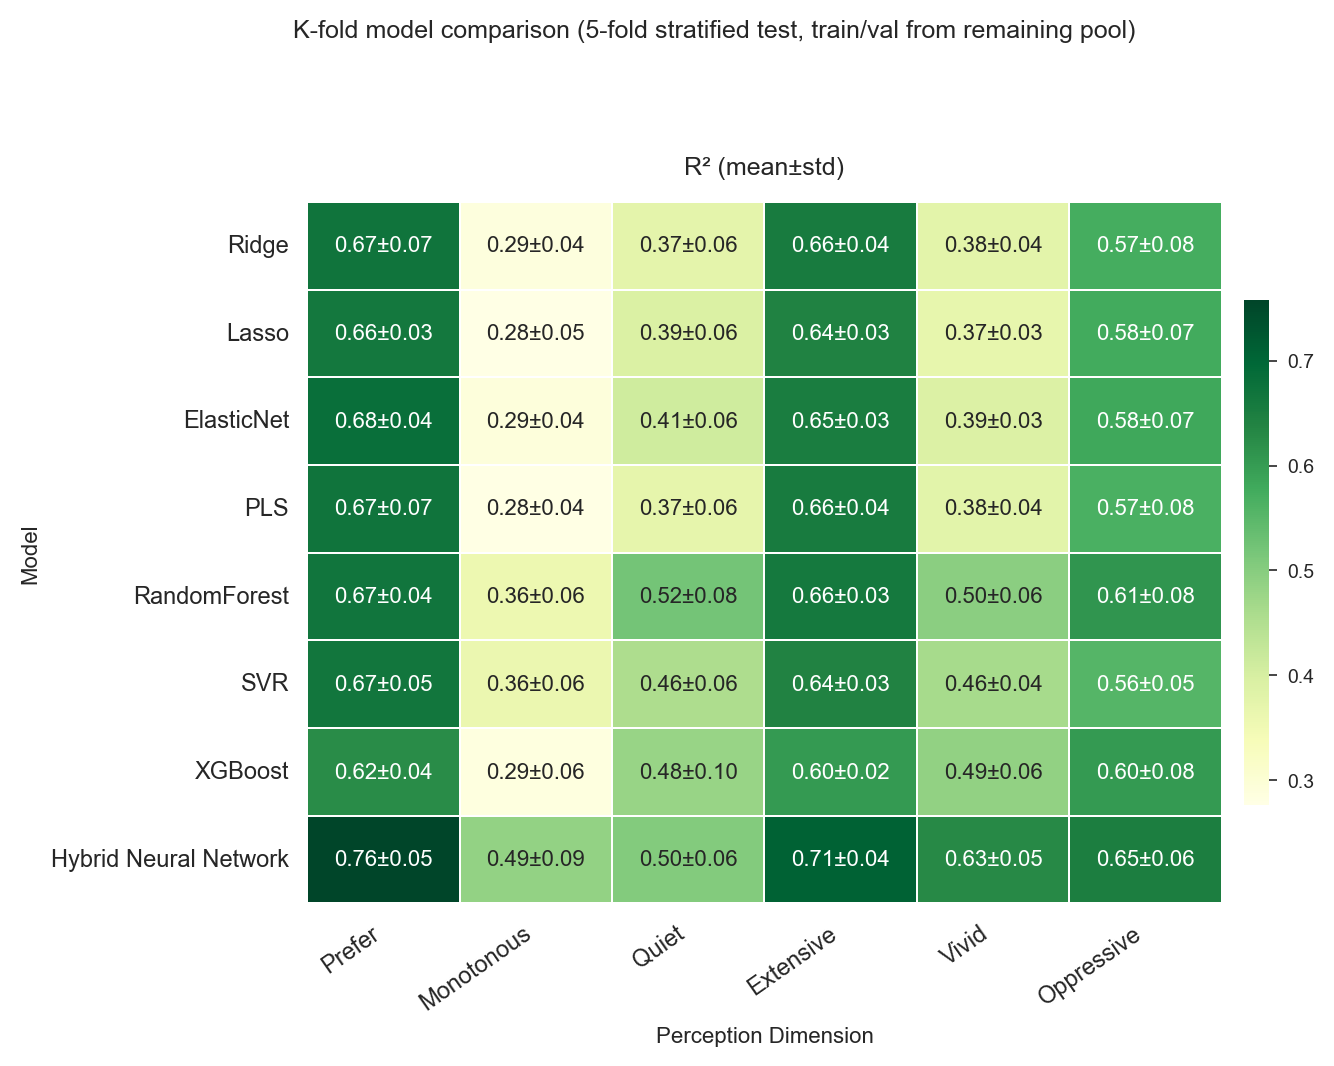

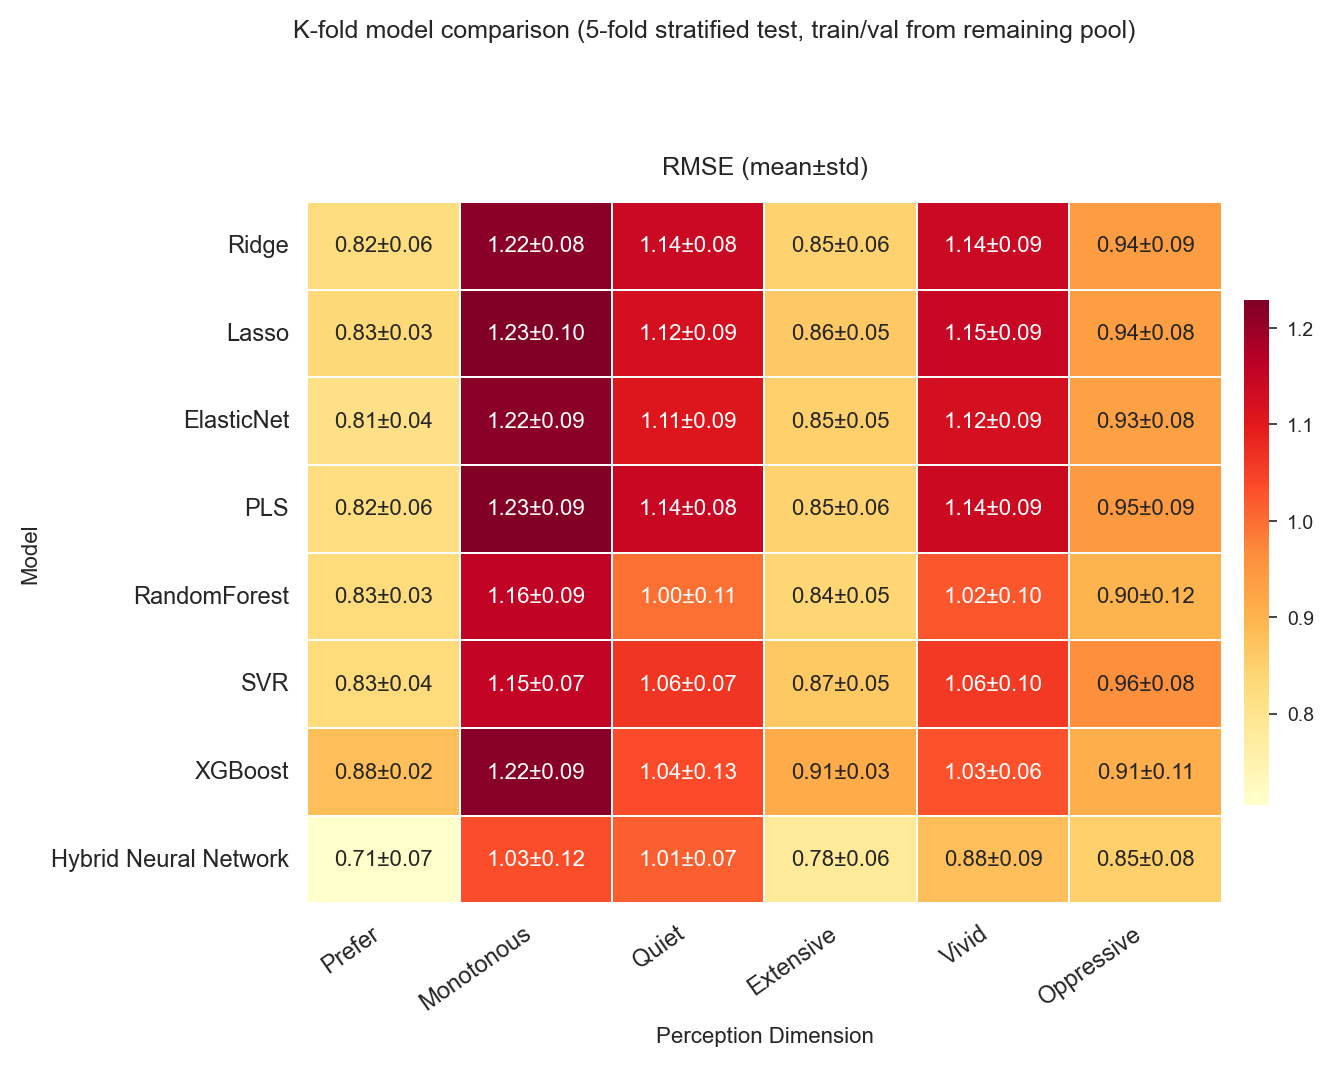

In [20]:
_kfold_subtitle = f"{N_FOLDS}-fold stratified test, train/val from remaining pool"

for mean_df, std_df, title, cmap, basename in [
    (r2_mean_df, r2_std_df, "R² (mean±std)", "YlGn", "figures/code3_model_comparison_kfold_r2_heatmap"),
    (rmse_mean_df, rmse_std_df, "RMSE (mean±std)", "YlOrRd", "figures/code3_model_comparison_kfold_rmse_heatmap"),
]:
    data = mean_df.astype(float)
    annot = heatmap_mean_std_annot(mean_df, std_df, nd=2)
    n_rows, n_cols = data.shape
    fig, ax = plt.subplots(figsize=kfold_heatmap_figsize(n_rows, n_cols))
    sns.heatmap(
        data,
        ax=ax,
        annot=annot,
        fmt="",
        cmap=cmap,
        linewidths=0.6,
        linecolor="white",
        square=False,
        annot_kws={"size": 8},
        cbar_kws={"shrink": 0.72, "pad": 0.02},
    )
    ax.set_title(title, pad=10)
    ax.set_xlabel("Perception Dimension")
    ax.set_ylabel("Model")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
    ax.tick_params(axis="x", labelsize=8.5)
    ax.tick_params(axis="y", labelsize=8.5)
    fig.suptitle(f"K-fold model comparison ({_kfold_subtitle})", y=1.02, fontsize=9)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    savefig_all(fig, basename)
    plt.show()

## 5. Reported Best-Model Performance

We trained the model on a **stratified** 60/20/20 train/validation/test split by score bins [0,1)–[4,5] (`SPLIT_SEED=42`). The checkpoint is selected on validation R². Tables below report **R², MSE, and RMSE** from `model_outputs/best_model_{dim}_metrics.txt` (and `best_model_metrics_summary.csv`).


Best-checkpoint metrics (selected on validation R²):

R²:
            train_r2  val_r2  test_r2
dimension                            
prefer         0.894   0.849    0.811
monotonous     0.705   0.484    0.584
quiet          0.850   0.601    0.560
extensive      0.895   0.690    0.750
vivid          0.840   0.701    0.684
oppressive     0.799   0.648    0.747

MSE:
            train_mse  val_mse  test_mse
dimension                               
prefer         0.2192   0.3380    0.3837
monotonous     0.6539   0.9776    0.7882
quiet          0.3155   0.8684    0.8598
extensive      0.2257   0.6308    0.4982
vivid          0.3635   0.5450    0.5675
oppressive     0.4591   0.5344    0.5308

RMSE:
            train_rmse  val_rmse  test_rmse
dimension                                  
prefer          0.4681    0.5814     0.6194
monotonous      0.8086    0.9887     0.8878
quiet           0.5617    0.9319     0.9273
extensive       0.4751    0.7942     0.7058
vivid           0.6029    0.7382 

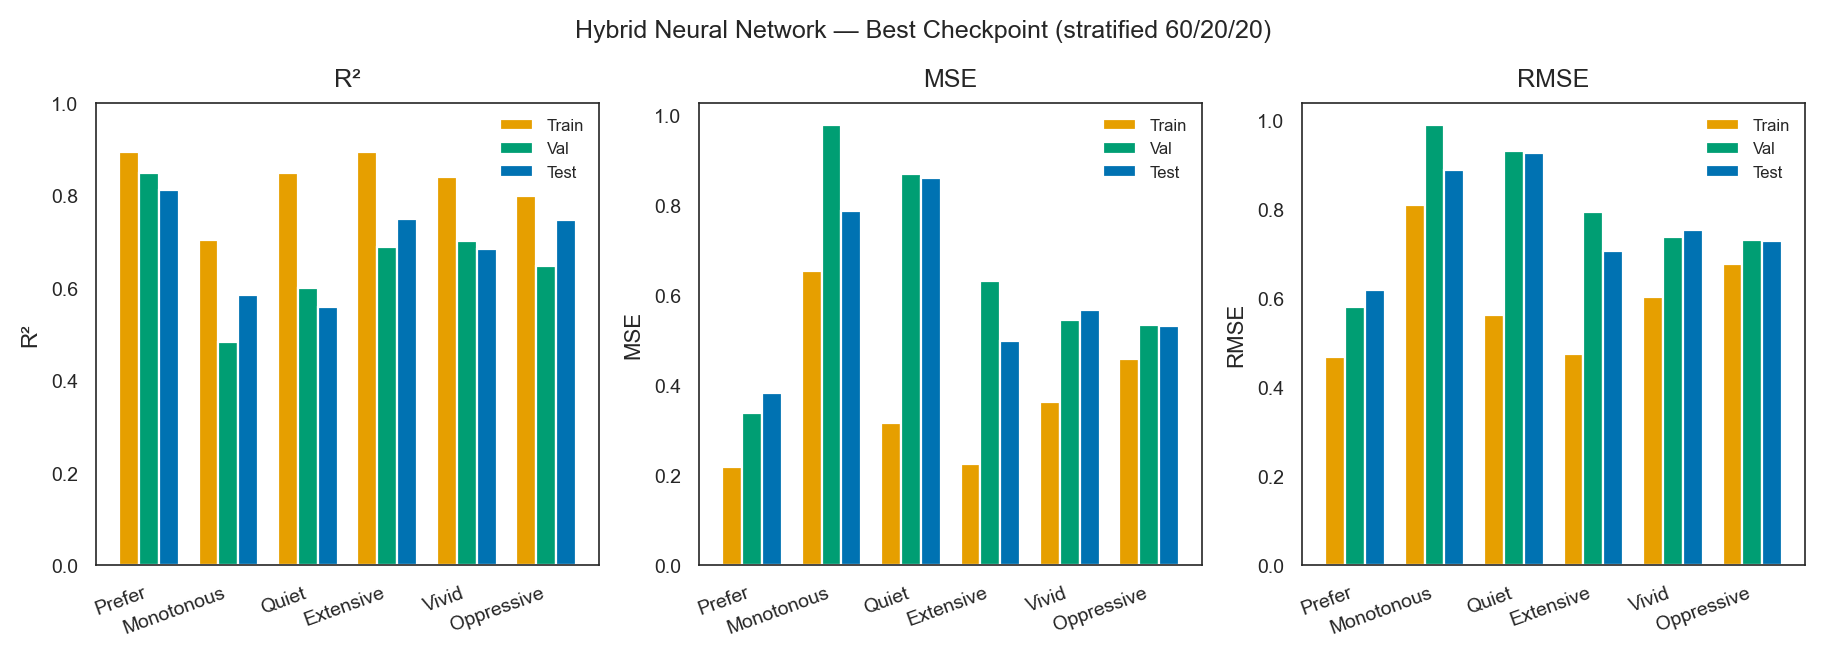

In [25]:
# --- §5 bootstrap (run after §4, or standalone) ---
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL_OUTPUT_DIR = Path("model_outputs")
PERCEPTION_DIMS = ["prefer", "monotonous", "quiet", "extensive", "vivid", "oppressive"]
INCH_PER_MM = 1.0 / 25.4
DOUBLE_COL_WIDTH = 183 * INCH_PER_MM
FIG_WIDTH_WIDE = 280 * INCH_PER_MM  # wider than double column for 3-panel bar chart
FIG_HEIGHT_MEDIUM = 3.0
OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000000"]


def savefig_all(fig, basename, png_dpi=300, tight=True):
    out_base = Path(basename)
    out_base.parent.mkdir(parents=True, exist_ok=True)
    kwargs = {"bbox_inches": "tight", "pad_inches": 0.01} if tight else {}
    fig.savefig(str(out_base.with_suffix(".png")), dpi=png_dpi, **kwargs)
    fig.savefig(str(out_base.with_suffix(".svg")), **kwargs)


def parse_metrics_txt(p: Path) -> dict:
    text = p.read_text()
    out = {"file": p.name}
    for split in ("Train", "Validation", "Test"):
        m = re.search(
            rf"{split} - Loss: ([\d.]+), R2: ([\d.]+), MSE: ([\d.]+), MAE: ([\d.]+), RMSE: ([\d.]+)",
            text,
        )
        if m:
            key = split.lower() if split != "Validation" else "val"
            out[f"{key}_loss"] = float(m.group(1))
            out[f"{key}_r2"] = float(m.group(2))
            out[f"{key}_mse"] = float(m.group(3))
            out[f"{key}_mae"] = float(m.group(4))
            out[f"{key}_rmse"] = float(m.group(5))
    return out

rows = []
for dim in PERCEPTION_DIMS:
    p = MODEL_OUTPUT_DIR / f"best_model_{dim}_metrics.txt"
    if p.exists():
        row = parse_metrics_txt(p)
        row["dimension"] = dim
        rows.append(row)

if rows:
    perf = pd.DataFrame(rows).set_index("dimension")
    metric_cols = [
        "train_r2", "val_r2", "test_r2",
        "train_mse", "val_mse", "test_mse",
        "train_rmse", "val_rmse", "test_rmse",
    ]
    perf = perf[[c for c in metric_cols if c in perf.columns]]

    summary_path = MODEL_OUTPUT_DIR / "best_model_metrics_summary.csv"
    perf.reset_index().to_csv(summary_path, index=False)
    print("Best-checkpoint metrics (selected on validation R²):")
    print("\nR²:")
    print(perf[["train_r2", "val_r2", "test_r2"]].round(3).to_string())
    print("\nMSE:")
    print(perf[["train_mse", "val_mse", "test_mse"]].round(4).to_string())
    print("\nRMSE:")
    print(perf[["train_rmse", "val_rmse", "test_rmse"]].round(4).to_string())
    print(f"\nSaved → {summary_path}")

    fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH_WIDE, FIG_HEIGHT_MEDIUM))
    x = np.arange(len(perf.index))
    width = 0.25
    labels = [d.capitalize() for d in perf.index]

    for ax, col, title, ylabel in zip(
        axes,
        [("train_r2", "val_r2", "test_r2"), ("train_mse", "val_mse", "test_mse"), ("train_rmse", "val_rmse", "test_rmse")],
        ["R²", "MSE", "RMSE"],
        ["R²", "MSE", "RMSE"],
    ):
        ax.bar(x - width, perf[col[0]], width, color=OKABE_ITO[0], label="Train")
        ax.bar(x, perf[col[1]], width, color=OKABE_ITO[2], label="Val")
        ax.bar(x + width, perf[col[2]], width, color=OKABE_ITO[4], label="Test")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        if title == "R²":
            ax.set_ylim(0, 1)
        ax.legend(loc="best", fontsize=6)

    fig.suptitle("Hybrid Neural Network — Best Checkpoint (stratified 60/20/20)", y=1.02, fontsize=9)
    savefig_all(fig, "figures/code3_best_model_metrics")
    plt.show()
else:
    print(f"No metrics text files found under {MODEL_OUTPUT_DIR}.")


## 6. City-scale Inference (standalone)

Score every pre-processed WVI using checkpoints in `model_outputs/`. **Run the code cell below only** (no need to re-run §0–§5 if checkpoints exist).

| Input | Path |
|-------|------|
| Images | `data/inference_images/WVI_Processed/` (`.jpg` or `.png`) |
| Tabular features | `data/inference_features/Features.csv` (same 24 aux columns as training) |
| Output | `data/inference_predictions/predictions_{dim}.csv` |

Set `RUN_CITY_INFERENCE = True` to predict all six dimensions. Set `RUN_CITY_INFERENCE = False` for a quick training-set demo on `data/training_images/`.


In [26]:
# --- §6 bootstrap (standalone: no §0–§5 required if checkpoints exist) ---
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm

import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

PERCEPTION_DIMS = ["prefer", "monotonous", "quiet", "extensive", "vivid", "oppressive"]
TRAINING_META_COLS = frozenset({"ID", "SampleWeight"})
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

MODEL_OUTPUT_DIR = Path("model_outputs")
FEATURES_DIR = Path("data/training_features")
INFERENCE_IMAGES_DIR = Path("data/inference_images/WVI_Processed")
INFERENCE_FEATURES_CSV = Path("data/inference_features/Features.csv")
INFERENCE_PREDICTIONS_DIR = Path("data/inference_predictions")
TRAIN_IMG_DIR = Path("data/training_images/WVI_Processed")


def training_aux_feature_columns(columns, dim: str) -> list[str]:
    return [c for c in columns if c not in TRAINING_META_COLS and c != dim]


def list_processed_images(folder: Path) -> list[Path]:
    folder = Path(folder)
    paths: list[Path] = []
    for ext in IMAGE_EXTENSIONS:
        paths.extend(folder.glob(f"*{ext}"))
    return sorted(paths, key=lambda p: p.stem)


def reference_aux_columns(dim: str = "oppressive") -> list[str]:
    """Column order must match TrainingFeatures_{dim}.csv (24 aux features)."""
    ref = pd.read_csv(FEATURES_DIR / f"TrainingFeatures_{dim}.csv", nrows=0)
    return training_aux_feature_columns(ref.columns, dim)


class WindowSceneRegressor(nn.Module):
    def __init__(self, num_aux_features: int, dropout: float = 0.5):
        super().__init__()
        self.backbone = resnet50(weights=ResNet50_Weights.DEFAULT)
        cnn_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.head = nn.Sequential(
            nn.Linear(cnn_dim + num_aux_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 1),
        )

    def forward(self, image, aux):
        return self.head(torch.cat((self.backbone(image), aux), dim=1))


def load_model(num_aux_features: int) -> WindowSceneRegressor:
    return WindowSceneRegressor(num_aux_features)


eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


@torch.no_grad()
def predict_folder(
    dim: str,
    image_folder: str | Path,
    checkpoint_path: str | Path,
    aux_features_csv: str | Path,
    aux_cols: list[str] | None = None,
    device: str | None = None,
    show_progress: bool = True,
) -> pd.DataFrame:
    """Score images in `image_folder` with a trained checkpoint.

    `aux_features_csv` needs `ID` plus the same aux columns as `TrainingFeatures_{dim}.csv`.
    Supports `.jpg` and `.png` (inference WVIs are usually `.png`).
    """
    if aux_cols is None:
        aux_cols = reference_aux_columns(dim)
    device = device or (
        "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    )
    aux_df = pd.read_csv(aux_features_csv)
    aux_df["ID"] = aux_df["ID"].astype(str)
    aux_df = aux_df.drop(columns=[c for c in PERCEPTION_DIMS if c in aux_df.columns], errors="ignore")
    missing = [c for c in aux_cols if c not in aux_df.columns]
    if missing:
        raise ValueError(f"[{dim}] {aux_features_csv} missing columns: {missing}")
    aux_lookup = aux_df.set_index("ID")[aux_cols]

    n_aux = len(aux_cols)
    model = load_model(n_aux).to(device)
    state = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state)
    model.eval()

    scaler_path = Path(checkpoint_path).parent / f"aux_scaler_{dim}.joblib"
    aux_scaler = joblib.load(scaler_path) if scaler_path.exists() else None
    if aux_scaler is None:
        print(f"Warning: {scaler_path} not found — using unscaled aux features.")

    image_paths = list_processed_images(image_folder)
    iterator = tqdm(image_paths, desc=f"predict {dim}") if show_progress else image_paths
    rows = []
    for path in iterator:
        img_id = path.stem
        if img_id not in aux_lookup.index:
            continue
        image = eval_transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
        aux_row = aux_lookup.loc[img_id].values.astype(np.float64).reshape(1, -1)
        if aux_scaler is not None:
            aux_row = aux_scaler.transform(aux_row)
        aux = torch.tensor(aux_row.astype(np.float32)).to(device)
        score = model(image, aux).item()
        rows.append({"ID": img_id, dim: score})
    return pd.DataFrame(rows)


RUN_CITY_INFERENCE = True  # all 6 dims on inference_images + inference_features
RUN_TRAINING_DEMO = False  # quick smoke test on training set (one dim)

if RUN_CITY_INFERENCE:
    INFERENCE_PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
    aux_cols = reference_aux_columns("oppressive")
    n_img = len(list_processed_images(INFERENCE_IMAGES_DIR))
    print(f"City inference: {n_img} images, {len(aux_cols)} aux features")
    for dim in PERCEPTION_DIMS:
        ckpt = MODEL_OUTPUT_DIR / f"best_model_{dim}.pth"
        if not ckpt.exists():
            print(f"  skip {dim} — missing {ckpt}")
            continue
        print(f"\n=== {dim} ===")
        preds = predict_folder(
            dim,
            INFERENCE_IMAGES_DIR,
            ckpt,
            INFERENCE_FEATURES_CSV,
            aux_cols=aux_cols,
        )
        out_path = INFERENCE_PREDICTIONS_DIR / f"predictions_{dim}.csv"
        preds.to_csv(out_path, index=False)
        print(f"  wrote {len(preds)} rows → {out_path.resolve()}")
elif RUN_TRAINING_DEMO:
    preds = predict_folder(
        "oppressive",
        TRAIN_IMG_DIR,
        MODEL_OUTPUT_DIR / "best_model_oppressive.pth",
        FEATURES_DIR / "Features.csv",
    )
    print(preds.head())
else:
    print("Set RUN_CITY_INFERENCE=True (city-scale) or RUN_TRAINING_DEMO=True (smoke test).")

City inference: 12334 images, 24 aux features

=== prefer ===


predict prefer:   0%|          | 0/12334 [00:00<?, ?it/s]

  wrote 12334 rows → /Users/sijieyang/Documents/GitHub/City-Landscape-In-Sight/data/inference_predictions/predictions_prefer.csv

=== monotonous ===


predict monotonous:   0%|          | 0/12334 [00:00<?, ?it/s]

  wrote 12334 rows → /Users/sijieyang/Documents/GitHub/City-Landscape-In-Sight/data/inference_predictions/predictions_monotonous.csv

=== quiet ===


...

  wrote 12334 rows → /Users/sijieyang/Documents/GitHub/City-Landscape-In-Sight/data/inference_predictions/predictions_extensive.csv

=== vivid ===


predict vivid:   0%|          | 0/12334 [00:00<?, ?it/s]

  wrote 12334 rows → /Users/sijieyang/Documents/GitHub/City-Landscape-In-Sight/data/inference_predictions/predictions_vivid.csv

=== oppressive ===


predict oppressive:   0%|          | 0/12334 [00:00<?, ?it/s]

  wrote 12334 rows → /Users/sijieyang/Documents/GitHub/City-Landscape-In-Sight/data/inference_predictions/predictions_oppressive.csv


## 7. (Optional) Grad‑CAM Visual Saliency

When interpretability is needed, Grad‑CAM highlights which image regions most influenced the predicted score.  The snippet below is provided for reference; it is not executed by default.


In [13]:
GRADCAM_CODE = '''
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

def saliency_overlay(model, image_path, target_layer="backbone.layer4.2.conv3"):
    model.eval()
    cam = GradCAM(model, target_layer)
    img = Image.open(image_path).convert("RGB")
    x = eval_transform(img).unsqueeze(0).requires_grad_(True)
    out = model(x, torch.zeros(1, model.head[0].in_features - 2048))
    activation_map = cam(0, out)
    if isinstance(activation_map, list):
        activation_map = torch.stack(activation_map).mean(0)
    return overlay_mask(to_pil_image(x.squeeze(0)), to_pil_image(activation_map.squeeze(), mode="F"), alpha=0.5)
'''
print(GRADCAM_CODE.strip())

from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

def saliency_overlay(model, image_path, target_layer="backbone.layer4.2.conv3"):
    model.eval()
    cam = GradCAM(model, target_layer)
    img = Image.open(image_path).convert("RGB")
    x = eval_transform(img).unsqueeze(0).requires_grad_(True)
    out = model(x, torch.zeros(1, model.head[0].in_features - 2048))
    activation_map = cam(0, out)
    if isinstance(activation_map, list):
        activation_map = torch.stack(activation_map).mean(0)
    return overlay_mask(to_pil_image(x.squeeze(0)), to_pil_image(activation_map.squeeze(), mode="F"), alpha=0.5)


**Summary.** Code 3 trains and evaluates the ResNet-50 + tabular-features regression model (K-fold CV, multi-model benchmark, inference). Image pre-processing and visual feature extraction live in **Code 2**. The trained checkpoints (one per dimension) are stored under `model_outputs/` and reach test‑set $R^2 \in [0.5, 0.7]$. **Code 5** deploys these checkpoints to score the full city-wide WVI dataset.